In [1]:
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture, CircularAnnulus, ApertureStats, aperture_photometry
from acstools import acszpt
import math

In [2]:
ngc7293 = fits.open('hlsp_heritage_hst_acs-wfc_helix-q2_f658n_v1_img_drz.fits')
ngc7293

In [3]:
#always look at number of parts
ngc7293[0].data

array([[0.        , 0.        , 0.        , ..., 0.06460703, 0.05022512,
        0.04587691],
       [0.        , 0.        , 0.        , ..., 0.06526387, 0.04347126,
        0.04407674],
       [0.        , 0.        , 0.        , ..., 0.05979887, 0.03973091,
        0.04156787],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], dtype='>f4')

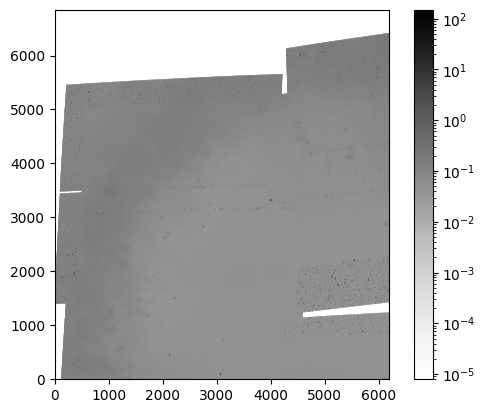

In [4]:
plt.figure()
plt.imshow(ngc7293[0].data, origin= 'lower',cmap = 'Greys', norm = LogNorm()) #use the norm accordingly
plt.colorbar()
plt.show()

vmin = 0.0005317163304425774 , vmax = 136.6311645507813

vmin = 0.01990268006920814, vmax = 0.4728906154632569
#vmin and vmix from section 2 [1000:1500, 1000:1500], but they are rounded off for plots

Text(0.5, 1.0, 'Section of NGC 7293 (Helix Nebula) from Hubble')

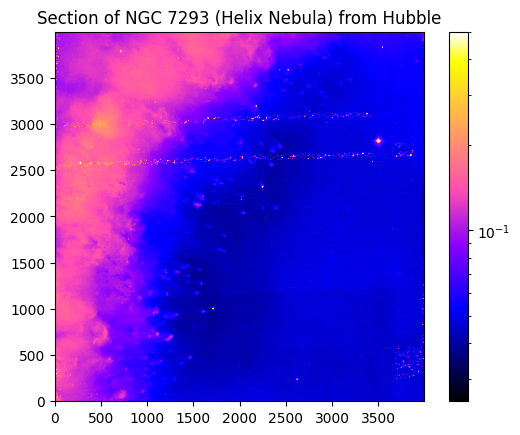

In [5]:
section1 = ngc7293[0].data[500:4500, 500:4500]
plt.figure()
plt.imshow(section1, origin= 'lower', cmap = 'gnuplot2', norm= LogNorm(vmin = 0.025, vmax = 0.5))
plt.colorbar()
plt.title('Section of NGC 7293 (Helix Nebula) from Hubble')

Text(0.5, 1.0, 'NGC 7293 (with subsection)')

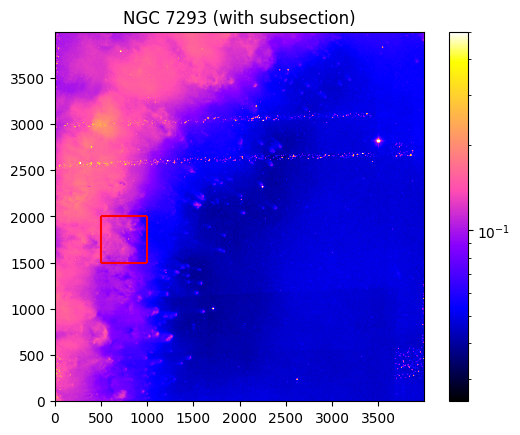

In [6]:
section1 = ngc7293[0].data[500:4500, 500:4500]
plt.figure()
plt.imshow(section1, origin= 'lower', cmap = 'gnuplot2', norm= LogNorm(vmin = 0.025, vmax = 0.5))
plt.vlines(x = 500, ymin= 1500, ymax= 2000, color = 'r')
plt.vlines(x = 1000, ymin= 1500, ymax= 2000, color = 'r')
plt.hlines(y = 1500, xmin= 500, xmax= 1000, color = 'r')
plt.hlines(y = 2000, xmin= 500, xmax= 1000, color = 'r')
plt.colorbar()
plt.title('NGC 7293 (with subsection)')

In [7]:
#if you want to change vmin and vmax, remove them from LogNorm and check c.vmin and c.vmax, then apply these new values to LogNorm

Text(0.5, 1.0, 'Subsection of NGC 7293 (Helix Nebula) from Hubble')

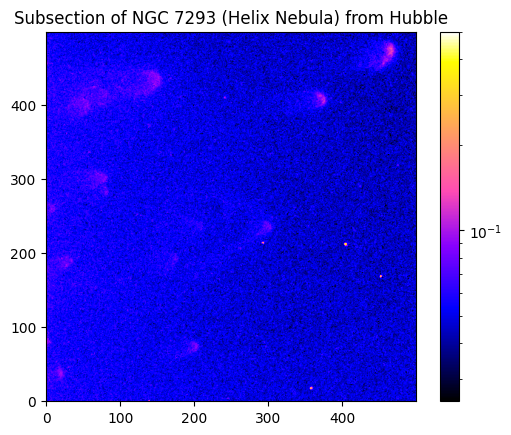

In [8]:
section2 = ngc7293[0].data[500:1000, 1500:2000]
plt.figure()
img = plt.imshow(section2, origin= 'lower', cmap = 'gnuplot2', norm= LogNorm(vmin = 0.025, vmax = 0.5))
c = plt.colorbar(img)
plt.title('Subsection of NGC 7293 (Helix Nebula) from Hubble')

In [9]:
mean, median, std = sigma_clipped_stats(section2, sigma = 3.0)

In [10]:
daofind = DAOStarFinder(fwhm= 3.0, threshold= 5.0 * std) 
#find all stars with fwhm of 3.0 pixel and 5*std above the background level

sources = daofind(section2 - median)

In [11]:
sources

id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,sky,peak,flux,mag
int32,float64,float64,float64,float32,float64,int32,float64,float64,float64,float64
1,357.75190879666894,16.970275244598962,0.5313011817101455,0.2676392,-0.20279203065689716,25,0.0,0.25274622440338135,5.582437992095947,-1.8670597694213278
2,175.12381006314465,58.24983401662368,0.541475627486642,-0.4180496,-0.8474378271590792,25,0.0,0.03852351754903793,1.0929368734359741,-0.09648769602214251
3,451.95847977762435,168.12043041005074,0.9962246303722244,0.50521725,0.31556363415513367,25,0.0,0.5750991702079773,10.013442993164062,-2.5014585742771582
4,404.3351337957926,211.63057414401862,0.6873623541302087,-0.48021358,-0.11025700044481482,25,0.0,0.5522007942199707,11.095582008361816,-2.6128752191894726
5,292.7869702873668,213.5151500798438,0.7295860152642937,0.078377776,-0.024971439865455823,25,0.0,0.2234533131122589,4.473605155944824,-1.6266441256635003
6,475.1019507091287,318.3083652890819,0.6669249752601814,0.119727984,0.12885491759775441,25,0.0,0.04842498153448105,1.1299545764923096,-0.13265246363057628
7,241.2729238050635,409.5654354028082,0.547481408496612,-0.09177623,0.08891884754245398,25,0.0,0.0668000876903534,1.5644137859344482,-0.48587908597202806
8,64.45348519679733,423.7756934755181,0.6388502028233887,0.28998092,-0.4390635123348592,25,0.0,0.0644768550992012,1.003144383430481,-0.0034086147403092184


for col in sources.colnames:
    if col not in ('id', 'npix'):
        sources[col].info.format = '%.3f'
sources.pprint(max_width = 80)

Text(0.5, 1.0, 'Stars found in the subsection of NGC 7293')

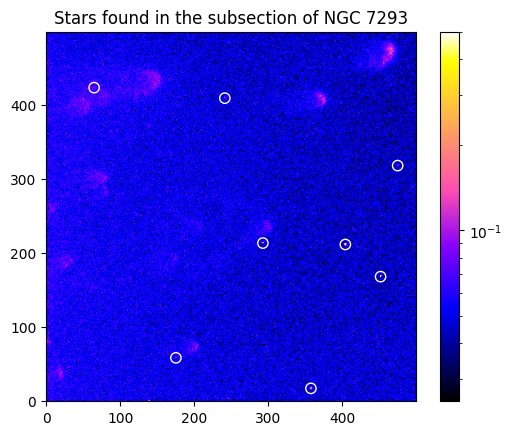

In [12]:
#find and circle the stars
positions = np.transpose((sources['xcentroid'],sources['ycentroid']))
apertures = CircularAperture(positions= positions, r = 7.0 ) #circles with radius r
plt.imshow(section2,  origin= 'lower', cmap = 'gnuplot2', norm= LogNorm(vmin = 0.025, vmax = 0.5), interpolation= 'nearest')
apertures.plot(color = 'white', lw = 1, alpha = 1.0); #without semi coloumn you get a list of circle names
plt.colorbar()
plt.title('Stars found in the subsection of NGC 7293')

Text(0.5, 1.0, 'Stars found in the subsection of NGC 7293')

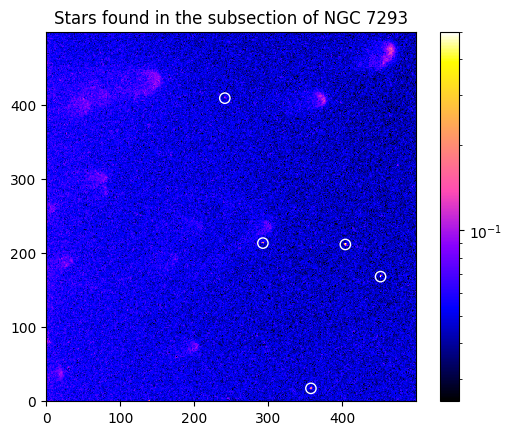

In [13]:
#apply mask incase the stars found are effectd by faulty gas clouds or so , usually done around bright stars
mask = np.zeros(section2.shape, dtype = bool)
mask[400:500, 10: 100] = True
mask[300:400, 400: 500] = True
mask[0:100, 100: 200] = True

#goingback again and remove the faulty one
sources = daofind(section2 - median, mask = mask)
xvalues = sources['xcentroid']
yvalues = sources['ycentroid']

positions = np.transpose((xvalues, yvalues))
apertures = CircularAperture(positions= positions, r = 7.0 ) #circles with radius r
plt.imshow(section2,  origin= 'lower', cmap = 'gnuplot2', norm= LogNorm(vmin = 0.025, vmax = 0.5), interpolation= 'nearest')
apertures.plot(color = 'white', lw = 1, alpha = 1.0); #without semi coloumn you get a list of circle names
plt.colorbar()
plt.title('Stars found in the subsection of NGC 7293')

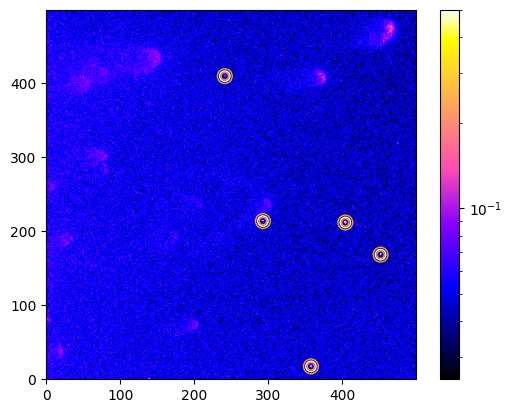

In [14]:
#aperature photometry, first make annulus around each star
annulus_aperature = CircularAnnulus(positions= positions, r_in = 5, r_out= 10) #inner and outer radius of annulus
plt.figure()
plt.imshow(section2,  origin= 'lower', cmap = 'gnuplot2', norm= LogNorm(vmin = 0.025, vmax = 0.5), interpolation= 'nearest')
apertures.plot(color = 'white', lw = 1, alpha = 1.0); #without semi coloumn you get a list of circle names
annulus_aperature.plot(color = 'orange',lw = 1, alpha = 1.0);
plt.colorbar()

In [15]:
#brigheness of the flux inbetween 2 rings of annulus, also defines background
aperstats = ApertureStats(section2, annulus_aperature) #be careful of the mask
bkg_mean = aperstats.mean
aperture_area = apertures.area_overlap(section2)
total_bkg = bkg_mean * aperture_area

star_data = aperture_photometry(section2, apertures)
star_data['total_bkg'] = total_bkg

In [16]:
star_data #this is aperture photometry

id,xcenter,ycenter,aperture_sum,total_bkg
,pix,pix,,
int32,float64,float64,float64,float64
1,357.75190879666894,16.970275244598962,8.879954440612043,7.412280600084805
2,451.95847977762435,168.12043041005074,8.086036529257534,6.811669859275785
3,404.3351337957926,211.63057414401862,9.714674616437954,6.741542645683312
4,292.7869702873668,213.5151500798438,8.326606594721436,7.480808208343253
5,241.2729238050635,409.5654354028082,7.841500531737777,7.282071480943325


In [17]:
#this reports the brightness of star in flux, but we want to do it in magnitude
#zero-point magnitude equation, finding zero point in exposure time
#use the 'more with fits file name' in terminal, but look for folders

In [18]:
date = '2003-05-27'
instrument = 'WFC'
filter = 'F658N'

#q = acszpt.Query(date= date, detector= instrument)
#zpt_table = q.fetch() #for all filters
q_filter = acszpt.Query(date= date, detector= instrument, filt= filter)
filter_zpt = q_filter.fetch()

In [19]:
filter_zpt #we have starmagnitude now, which is ABmag i.e., the zero point

Filter,PHOTLAM,PHOTFLAM,STmag,VEGAmag,ABmag
,Angstrom,erg / (Angstrom electron cm2),mag(ST),mag,mag(AB)
bytes5,float64,float64,float64,float64,float64
F658N,6584.0,1.9703e-18,23.164,22.393,22.763


In [20]:
zeropoint = 22.763
extime = 8260 #from hubble legacy archive

magnitudes = []
for line in star_data:
    magnitudes.append(zeropoint - (2.5 * math.log10(abs(line[3] - line[4])/ extime))) 
    #line[3] is magnitude i.e., aperture_sum from before and line[4] is total_bkg

star_data['magnitude'] = magnitudes
#star_data.pprint() #for saving the output
star_data

id,xcenter,ycenter,aperture_sum,total_bkg,magnitude
,pix,pix,,,
int32,float64,float64,float64,float64,float64
1,357.75190879666894,16.970275244598962,8.879954440612043,7.412280600084805,32.13887623445531
2,451.95847977762435,168.12043041005074,8.086036529257534,6.811669859275785,32.2922141074896
3,404.3351337957926,211.63057414401862,9.714674616437954,6.741542645683312,31.372414650789395
4,292.7869702873668,213.5151500798438,8.326606594721436,7.480808208343253,32.73728298764914
5,241.2729238050635,409.5654354028082,7.841500531737777,7.282071480943325,33.186087580158315


In [21]:
#using zero-point information , calculate the magnitudes of stars

In [22]:
star_data['magnitude'].data[0]

32.13887623445531

Text(0.5, 1.0, 'Stars and their magnitudes in the subsection of NGC 7293')

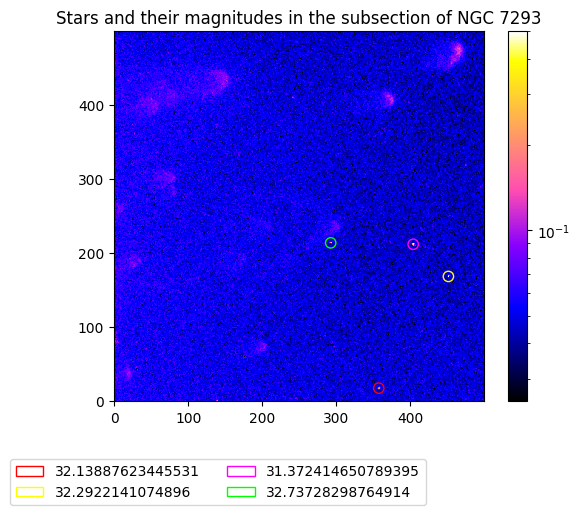

In [23]:
#apply mask incase the stars found are effectd by faulty gas clouds or so , usually done around bright stars
mask = np.zeros(section2.shape, dtype = bool)
mask[400:500, 10: 100] = True
mask[300:400, 400: 500] = True
mask[0:100, 100: 200] = True
mask[300:400, 200: 300] = True

#goingback again and remove the faulty one
sources = daofind(section2 - median, mask = mask)
xvalues = sources['xcentroid']
yvalues = sources['ycentroid']

positions = np.transpose((xvalues, yvalues))
apertures = CircularAperture(positions= positions, r = 7.0 ) #circles with radius r
plt.imshow(section2,  origin= 'lower', cmap = 'gnuplot2', norm= LogNorm(vmin = 0.025, vmax = 0.5), interpolation= 'nearest')
apertures[0].plot(color = 'red', lw = 1, alpha = 1.0, label = star_data['magnitude'].data[0])
apertures[1].plot(color = 'yellow', lw = 1, alpha = 1.0, label = star_data['magnitude'].data[1])
apertures[2].plot(color = 'magenta', lw = 1, alpha = 1.0, label = star_data['magnitude'].data[2])
apertures[3].plot(color = 'lime', lw = 1, alpha = 1.0, label = star_data['magnitude'].data[3])
#apertures[4].plot(color = 'orange', lw = 1, alpha = 1.0, label = star_data['magnitude'].data[4])
plt.colorbar()
plt.legend(loc = 'lower left', bbox_to_anchor = (-0.3, -0.3), ncol = 2)
plt.title('Stars and their magnitudes in the subsection of NGC 7293')

In [24]:
#identifies stars and their respective magnitudes based on zero=point info